<a href="https://colab.research.google.com/github/jdasam/ant5015/blob/2026/notebooks/3rd_week_pitch_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Synthesizing and Classifying Sine Waves

We start from scratch: generate audio with math, visualize it, and train a simple classifier.

## Sine Wave Synthesis

A sine wave at frequency $f$ (Hz) is:
$$x(t) = A \cdot \sin(2\pi f t)$$

Import the libraries, then build the wave sample-by-sample:
convert sample indices → seconds → radians → sine values.

In [2]:
import torch
import matplotlib.pyplot as plt
import IPython.display as ipd
from math import pi

torch.set_printoptions(sci_mode=False)

sr = 16000        # sample rate (samples/sec) #
frequency = 440   # Hz
amplitude = 0.5

# TODO: create sample_t with torch.arange
# TODO: convert to sec_t, compute accum_rad, then sin_value

audio_len = 3 # sec
num_sample = audio_len * sr

sample_t = torch.arange(0, 48000)
print(sample_t)

sec_t = sample_t / sr
print(sec_t)

sin_wav = amplitude * torch.sin(2 * pi * frequency * sec_t)


tensor([    0,     1,     2,  ..., 47997, 47998, 47999])
tensor([0.0000, 0.0001, 0.0001,  ..., 2.9998, 2.9999, 2.9999])


Plot the first 500 samples to confirm the wave shape.

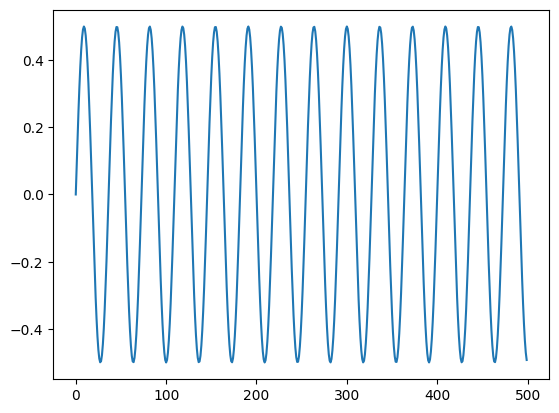

In [3]:
plt.plot(sin_wav[:500])


Listen to the result.

In [4]:
ipd.Audio(sin_wav, rate=sr)


Wrap the synthesis steps into a reusable function.

```python
def make_sine_wave(duration, sr, frequency, amplitude) -> torch.Tensor
```

In [14]:
def make_sine_wave(duration, sr, frequency, amplitude):
    # TODO: implement
    num_sample = duration * sr

    sample_t = torch.arange(0, num_sample)
    sec_t = sample_t / sr

    sin_wav = amplitude * torch.sin(2 * pi * frequency * sec_t)

    return sin_wav

sine_wave = make_sine_wave(3, 16000, 440, 2.5)
ipd.Audio(sine_wave, rate=sr, normalize=True)


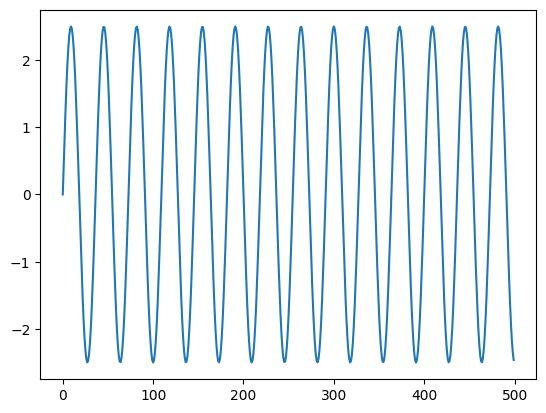

In [15]:
plt.plot(sine_wave[:500])

Save the waveform as a WAV file, then reload and plot it.

In [16]:
import torchaudio

# TODO: torchaudio.save('test.wav', ...) — remember to add a channel dim with .unsqueeze(0)
# current shape of sine_wave == [48000]
# to save this, using unsqueeze(0) -> [1, 48000]
# if use unsqueeze(1) -> [48000, 1]
torchaudio.save('test.wav', sine_wave.unsqueeze(0), sample_rate=16000)



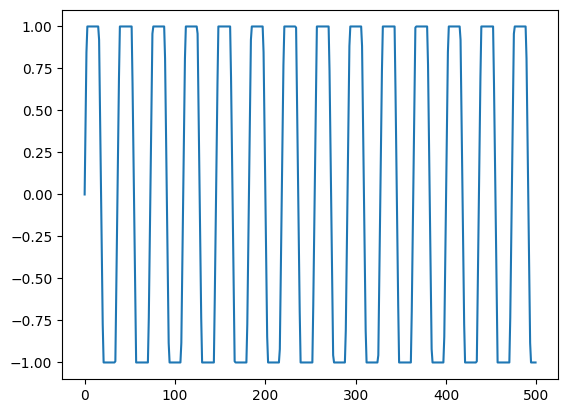

In [17]:
# TODO: load 'test.wav' and plot the first 1000 samples
sine_wave, _ = torchaudio.load('test.wav')
plt.plot(sine_wave[0, :500])
# we can see clipping


In [18]:
ipd.Audio(sine_wave, rate=16000)

## Time-Varying Frequency

When frequency changes over time, we can no longer multiply by a fixed $f$.
Instead, accumulate the instantaneous phase with `torch.cumsum`:

$$\phi[n] = \sum_{k=0}^{n} \frac{f[k] \cdot 2\pi}{sr}$$

First, build intuition for `torch.cumsum` with a small example.

In [21]:
dummy_tensor = torch.arange(10)
print(dummy_tensor)
# TODO: compute torch.cumsum(dummy_tensor, dim=0)
torch.cumsum(dummy_tensor, dim=0)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


tensor([ 0,  1,  3,  6, 10, 15, 21, 28, 36, 45])

Now implement `make_sine_wave_with_freq_seq(sr, freq_sequence, amplitude)` using `cumsum`, then create a vibrato effect by modulating frequency around 440 Hz.

In [33]:
freq_sequence = 440 + make_sine_wave(4, 16000, 4, 50)

freq_sequence, freq_sequence.shape
angular_speed = 2 * pi * freq_sequence

delta_phi = angular_speed * (1 / sr) # speed * time

cum_phi = torch.cumsum(delta_phi, dim=0)
sine_wave = amplitude * torch.sin(cum_phi)

ipd.Audio(sine_wave, rate=16000)

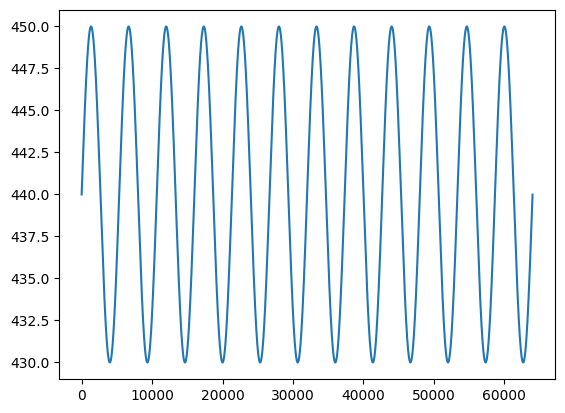

In [36]:
def make_sine_wave_with_freq_seq(sr, freq_sequence, amplitude):
    # TODO: accumulate phase with torch.cumsum, return torch.sin(...) * amplitude
    angular_speed = 2 * pi * freq_sequence

    delta_phi = angular_speed * (1 / sr) # speed * time

    cum_phi = torch.cumsum(delta_phi, dim=0)
    sine_wave = amplitude * torch.sin(cum_phi)

    return sine_wave

freq_sequence = 440 + make_sine_wave(4, 16000, 3, 10)
plt.plot(freq_sequence)
sine_with_vibrato = make_sine_wave_with_freq_seq(16000, freq_sequence, 0.5)
ipd.Audio(sine_with_vibrato * 0.4, rate=16000, normalize=False)


## Synthesizer Class

Refactor the function into a `SineGenerator` class with:
- `__call__(frequency, amplitude)` — single sine wave
- `make_random_wav(frequency)` — sum of 1–10 harmonics with amplitude $\propto 1/\sqrt{i+1}$

In [69]:
import random

class SineGenerator:
    def __init__(self, sr, duration):
        self.sr = sr
        self.duration = duration
        self.t = torch.arange(0, self.sr * self.duration)
        # TODO
        pass

    def __call__(self, frequency, amplitude):
        return amplitude * torch.sin(2 * pi * frequency * self.t / self.sr)
        # TODO
        pass

    def make_random_wav(self, frequency):
        # TODO: random number of harmonics, decreasing amplitude
        # randomly choose number of harmonics
        # randomly decide amplitude of each harmonic

        num_harmonics = random.randint(3, 10)
        total_out = []
        for i in range(1, num_harmonics+1):
          freq_harm = frequency * i
          amplitude = random.random() / (i ** 0.5)
          harm_wave = self(freq_harm, amplitude)
          total_out.append(harm_wave)
        # return torch.stack(total_out, dim=0).sum(0)
        return sum(total_out)

oscilator = SineGenerator(sr=16000, duration=4)
oscilator.sr, oscilator.duration
sine_wave = oscilator(440, 0.3)
ipd.Audio(oscilator(440, 0.3), rate=oscilator.sr)
ipd.Audio(oscilator.make_random_wav(442) * 0.09, rate=oscilator.sr, normalize=False)


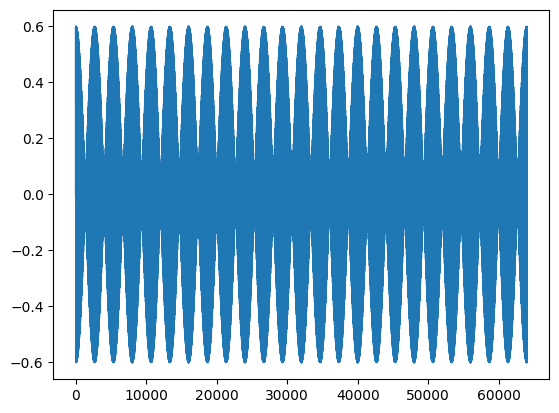

In [62]:
sum_wav = oscilator(440, 0.3) + oscilator(446, 0.3)
ipd.display(ipd.Audio(sum_wav, rate=oscilator.sr, normalize=False))
plt.plot(sum_wav)

Sum the first three harmonics of f0 = 220 Hz and listen to the result.

In [64]:
f0 = 220
f1 = f0 * 2
f2 = f0 * 3

# TODO: wav_harmonics = oscilator(f0, 0.5) + ...
# ipd.Audio(wav_harmonics * 0.2, rate=sr, normalize=False)

wav_harmonics = oscilator(f0, 0.5) + oscilator(f1, 0.2) + oscilator(f2, 0.3)
ipd.Audio(wav_harmonics * 0.2, rate=sr, normalize=False)


Plot `wav_sum` (the sum of two waves) to see constructive/destructive interference.

## Spectrogram Analysis

Convert a waveform to a 2-D time-frequency representation using the Short-Time Fourier Transform (STFT).
Use `torchaudio.transforms.Spectrogram` (n_fft=1024, hop_length=512) and `AmplitudeToDB`, then visualize.

In [101]:
# TODO: create spec_converter and db_converter
# TODO: compute spec = db_converter(spec_converter(wav_harmonics))
# TODO: plt.imshow(spec, origin='lower', aspect='auto')

spec_converter = torchaudio.transforms.Spectrogram(n_fft=1024, hop_length=512)
db_converter = torchaudio.transforms.AmplitudeToDB()

# target_wav = oscilator.make_random_wav(440)
target_wav = make_sine_wave_with_freq_seq(16000, freq_sequence, 0.5)
target_wav += make_sine_wave_with_freq_seq(16000, freq_sequence * 2, 0.2)
target_wav += make_sine_wave_with_freq_seq(16000, freq_sequence * 3, 0.1)

spec = spec_converter(target_wav)
spec = db_converter(spec)
spec.shape # freq_bin x time_frame

torch.Size([513, 126])

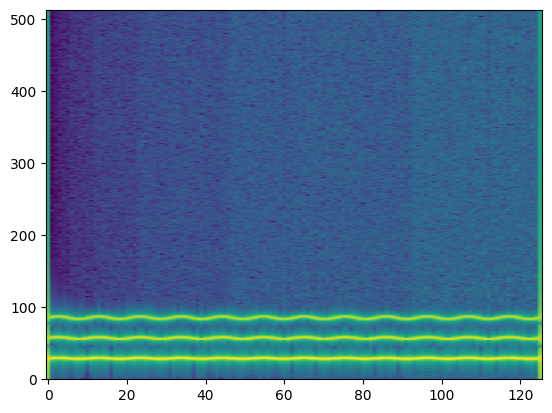

In [102]:
plt.imshow(spec, origin='lower', aspect='auto')

The spectrogram has shape `(F, T)`. Loop over time frames 45–54 and plot the first 200 frequency bins of each to see the spectral peaks.

torch.Size([513, 126])


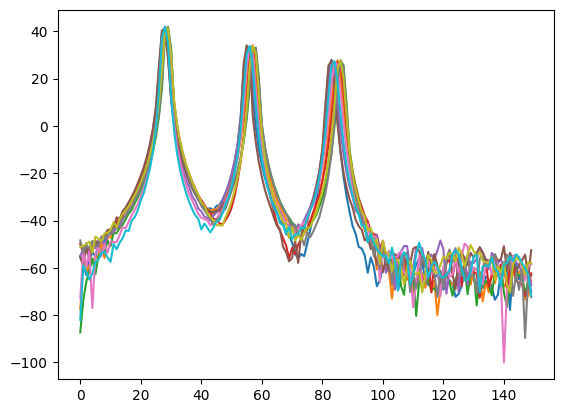

In [107]:
print(spec.shape)  # F x T
# TODO: loop over t_i in range(45, 55) and plot spec[:200, t_i]

for t_i in range(40, 60, 2):
    plt.plot(spec[:150, t_i])


## Building a Classifier

Generate 1000 random waveforms for each of four pitch classes `[220, 440, 660, 215]` using `oscilator.make_random_wav`. Store each `(wav, frequency_label)` pair in `training_data`.

In [108]:
from tqdm.auto import tqdm

freq_classes = [220, 440, 660, 215]
num_samples = 1000
training_data = []

# TODO: for each freq, generate num_samples random wavs and append (wav, freq) to training_data

for freq in freq_classes:
  for _ in tqdm(range(num_samples)):
    wav = oscilator.make_random_wav(freq)
    training_data.append( (wav, freq) )


In [109]:
training_data[185]

(tensor([ 0.0000,  0.7605,  1.2531,  ..., -1.3271, -1.2529, -0.7604]), 220)

Implement a `Dataset` class that converts each `(wav, label)` pair into a `(spectrum_vector, class_idx)` pair on the fly:
- compute dB spectrogram, extract the middle time frame, divide by 80
- convert frequency label to class index using `self.class_name.index(...)`

In [140]:
class Dataset:
    def __init__(self, data):
        # TODO: store data, collect sorted unique labels, create spec/db converters
        self.data = data
        self.spec_converter = torchaudio.transforms.Spectrogram(n_fft=1024, hop_length=512)
        self.db_converter = torchaudio.transforms.AmplitudeToDB()

        # self.label_name = [220, 440, 660, 215]
        self.label_name = sorted(list(set([x[1] for x in self.data])))
        # self.label2idx = {}
        # for i, name in enumerate(self.label_name):
        #   self.label2idx[name] = i
        self.label2idx = {name:i for i, name in enumerate(self.label_name)}

        pass

    def __len__(self):
        # how many data sample exists in the dataset?
        return len(self.data)
        pass

    def __getitem__(self, idx):
        # return idx-th item of the dataset
        # TODO: spectrogram -> middle frame / 80 -> (spectrum, class_idx)
        # return self.data[idx]

        audio, label = self.data[idx]
        # convert audio to spectrogram
        spec = self.spec_converter(audio)
        spec = self.db_converter(spec)
        spec /= 100 # neural network layer epxects input to be scale of -1 to 1

        return spec[:, 50], self.label2idx[label]

        pass

#         self.label_name = set([x[1] for x in self.data])

dataset = Dataset(training_data)
# len(dataset)
dataset[0]
# dataset.label_name


(tensor([-0.5505, -0.5168, -0.4338, -0.5007, -0.4037, -0.3704, -0.3307, -0.3405,
         -0.2597, -0.2215, -0.1629, -0.0862,  0.0287,  0.3455,  0.4164,  0.3664,
          0.0534, -0.0746, -0.1643, -0.2464, -0.3702, -0.3305, -0.2451, -0.1842,
         -0.1206, -0.0443,  0.0670,  0.3261,  0.4081,  0.3681,  0.1179, -0.0159,
         -0.1055, -0.1847, -0.2886, -0.3234, -0.2118, -0.1476, -0.0839, -0.0079,
          0.0995,  0.3256,  0.4195,  0.3891,  0.1768,  0.0370, -0.0527, -0.1258,
         -0.1996, -0.3968, -0.2341, -0.1521, -0.0839, -0.0076,  0.0967,  0.3002,
          0.4068,  0.3859,  0.2012,  0.0539, -0.0376, -0.1107, -0.1832, -0.3229,
         -0.2457, -0.1515, -0.0830, -0.0077,  0.0939,  0.2803,  0.4008,  0.3892,
          0.2266,  0.0712, -0.0206, -0.0873, -0.1409, -0.1887, -0.2363, -0.2923,
         -0.4330, -0.2317, -0.1124,  0.0656,  0.2020,  0.1996,  0.0557, -0.1104,
         -0.2105, -0.2942, -0.4415, -0.3737, -0.2839, -0.2265, -0.1673, -0.0976,
         -0.0034,  0.1578,  

Wrap in a `DataLoader` and pull out one batch.

In [141]:
data_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

# TODO: iterate once and unpack the first batch into (spectrum, label)
for batch in data_loader:
  # print(batch)
  spectrum, label = batch
  break


In [142]:
spectrum.shape, label.shape, label


(torch.Size([64, 513]),
 torch.Size([64]),
 tensor([1, 3, 3, 1, 2, 3, 0, 3, 0, 1, 1, 0, 1, 2, 1, 1, 1, 0, 3, 1, 3, 2, 1, 1,
         3, 3, 1, 2, 1, 0, 0, 0, 3, 3, 3, 3, 2, 0, 1, 3, 0, 3, 3, 2, 1, 1, 3, 3,
         1, 2, 2, 3, 1, 0, 2, 3, 3, 2, 3, 0, 1, 3, 1, 3]))

Define a `nn.Linear` model (513 → 4) and compute cross-entropy loss **manually**:
logit → softmax → probability of correct class → negative log-likelihood → mean.

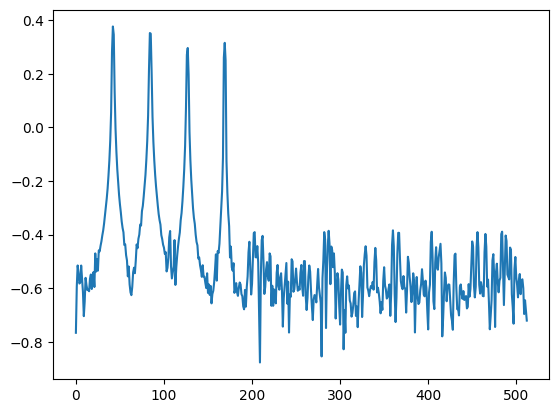

In [143]:
plt.plot(spectrum[5])

In [146]:
import torch.nn as nn

model = nn.Linear(in_features=513, out_features=4)
optimizer = torch.optim.Adam(model.parameters())

# TODO: logit = model(spectrum)
# TODO: prob -> prob_of_correct_class -> NLL -> loss

logit = model(spectrum)

In [152]:
# softmax
print(logit[:5])
exp_logit = logit.exp()
print(exp_logit[:5])
sum_exp_logit = exp_logit.sum(dim=-1, keepdim=True)
print(sum_exp_logit[:5])
prob_dist = exp_logit / sum_exp_logit
print(prob_dist[:5])

tensor([[-0.0370, -0.1317, -0.0917,  0.2594],
        [ 0.0307, -0.2327, -0.0351,  0.3322],
        [ 0.0289, -0.2152,  0.0175,  0.3696],
        [-0.1248, -0.1986,  0.0166,  0.4231],
        [-0.1477, -0.0850, -0.0956,  0.3663]], grad_fn=<SliceBackward0>)
tensor([[0.9636, 0.8766, 0.9124, 1.2961],
        [1.0312, 0.7924, 0.9655, 1.3940],
        [1.0294, 0.8064, 1.0177, 1.4472],
        [0.8827, 0.8199, 1.0167, 1.5267],
        [0.8627, 0.9186, 0.9088, 1.4424]], grad_fn=<SliceBackward0>)
tensor([[4.0488],
        [4.1831],
        [4.3006],
        [4.2460],
        [4.1325]], grad_fn=<SliceBackward0>)
tensor([[0.2380, 0.2165, 0.2253, 0.3201],
        [0.2465, 0.1894, 0.2308, 0.3332],
        [0.2394, 0.1875, 0.2366, 0.3365],
        [0.2079, 0.1931, 0.2395, 0.3596],
        [0.2088, 0.2223, 0.2199, 0.3490]], grad_fn=<SliceBackward0>)


In [154]:
nll = []
for i in range(len(label)):
  correct_class = label[i]
  prob_of_current_index = prob_dist[i]
  prob_of_correct_class = prob_of_current_index[correct_class]
  nll.append(prob_of_correct_class)
nll

[tensor(0.2165, grad_fn=<SelectBackward0>),
 tensor(0.3332, grad_fn=<SelectBackward0>),
 tensor(0.3365, grad_fn=<SelectBackward0>),
 tensor(0.1931, grad_fn=<SelectBackward0>),
 tensor(0.2199, grad_fn=<SelectBackward0>),
 tensor(0.3364, grad_fn=<SelectBackward0>),
 tensor(0.2346, grad_fn=<SelectBackward0>),
 tensor(0.3408, grad_fn=<SelectBackward0>),
 tensor(0.2396, grad_fn=<SelectBackward0>),
 tensor(0.1775, grad_fn=<SelectBackward0>),
 tensor(0.2094, grad_fn=<SelectBackward0>),
 tensor(0.2409, grad_fn=<SelectBackward0>),
 tensor(0.1616, grad_fn=<SelectBackward0>),
 tensor(0.2444, grad_fn=<SelectBackward0>),
 tensor(0.2141, grad_fn=<SelectBackward0>),
 tensor(0.2048, grad_fn=<SelectBackward0>),
 tensor(0.2196, grad_fn=<SelectBackward0>),
 tensor(0.2471, grad_fn=<SelectBackward0>),
 tensor(0.3327, grad_fn=<SelectBackward0>),
 tensor(0.1823, grad_fn=<SelectBackward0>),
 tensor(0.3652, grad_fn=<SelectBackward0>),
 tensor(0.2317, grad_fn=<SelectBackward0>),
 tensor(0.2318, grad_fn=<SelectB

In [162]:
prob_dist[:5], label[:5]

prob_of_correct_class = prob_dist[torch.arange(len(label)), label]
nll = -torch.log(prob_of_correct_class + 1e-8).mean()
nll

tensor(1.3752, grad_fn=<NegBackward0>)

Run the full training loop for 2 epochs. For each batch: forward → loss → `loss.backward()` → `optimizer.step()` → `optimizer.zero_grad()`.

In [164]:
loss_record = []
num_epochs = 2

for epoch in range(num_epochs):
    for batch in tqdm(data_loader):
        spectrum, label = batch
        logit = model(spectrum)
        prob = logit.softmax(dim=-1)
        nll = -torch.log(prob[torch.arange(len(label)), label] + 1e-8).mean()
        # TODO: compute loss, backprop, update, record
        nll.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_record.append(nll.item())


  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

Plot the loss curve and inspect the learned weight matrix.

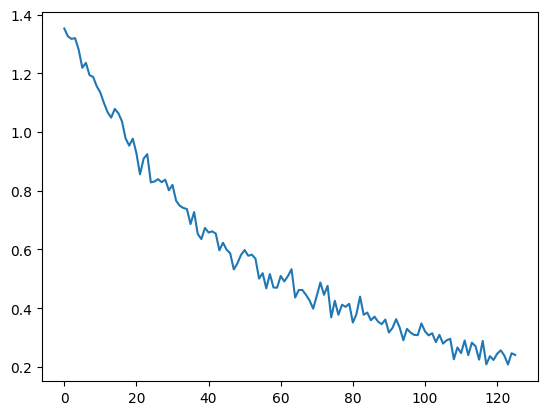

In [165]:
plt.plot(loss_record)


In [166]:
model.weight.shape


torch.Size([4, 513])

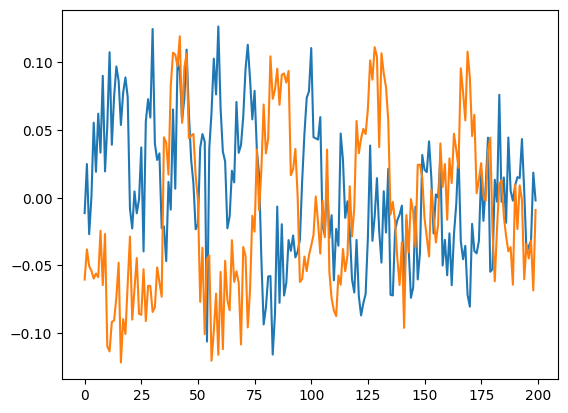

In [171]:
for idx in [1, 3]:
    plt.plot(model.weight[idx].data[:200])


---
# Part 2: Pitch Classification on the NSynth Dataset

We now solve the same classification problem on **real instrument recordings** from the [NSynth dataset](https://magenta.tensorflow.org/datasets/nsynth). The key differences:
- Input: real audio instead of synthetic sine waves
- Feature: **Mel spectrogram** (log-frequency scale) instead of linear spectrogram
- Output: ~120 MIDI pitch classes instead of 4

## Dataset Setup

Download the NSynth test split (~300 MB) and extract it. The archive contains a `nsynth-test/audio/` folder and an `examples.json` metadata file.

In [ ]:
# TODO: !wget http://download.magenta.tensorflow.org/datasets/nsynth/nsynth-test.jsonwav.tar.gz
# TODO: !tar -xf nsynth-test.jsonwav.tar.gz


Load `examples.json` into `meta`. Each key is a filename stem; each value is a dict with fields like `pitch`, `instrument_family`, `velocity`. Print the total count and inspect one entry.

In [ ]:
import json
from pathlib import Path

# TODO: meta = json.load(open('nsynth-test/examples.json'))
# TODO: print(len(meta)) and inspect list(meta.keys())[:5] and one full entry


Build `audio_fns`, a list of `Path` objects pointing to each WAV file. Assert every file exists, then load and listen to one example.

In [ ]:
import torchaudio
import IPython.display as ipd

audio_dir = Path('nsynth-test/audio')
fns = sorted(meta.keys())

# TODO: build audio_fns = [(audio_dir / fn).with_suffix('.wav') for fn in fns]
# TODO: assert every path exists
# TODO: load one file and display


## Mel Spectrogram

A regular spectrogram has **linearly** spaced frequency bins. The Mel scale compresses high frequencies (where pitch differences are less audible), mapping 513 linear bins down to ~80 Mel bins.

Inspect the filterbank matrix of `torchaudio.transforms.MelScale` (shape: `n_stft × n_mels`): visualize it with `plt.imshow` and overlay a few individual filters.

In [ ]:
import matplotlib.pyplot as plt

# TODO: mel_scale = torchaudio.transforms.MelScale(n_mels=80, sample_rate=16000,
#                                                   f_min=20, f_max=4000, n_stft=513)
# TODO: print shape, imshow filterbank, plot a few columns


Use `torchaudio.transforms.MelSpectrogram` + `AmplitudeToDB` to compute the Mel-dB spectrogram for one audio file and visualize it.

In [ ]:
# TODO: mel_db_conv = ... (chain MelSpectrogram and AmplitudeToDB)
# TODO: load one file, compute mel-dB spec, plt.imshow(..., origin='lower', aspect='auto')


## Classification

Collect all unique pitch values from `meta`, sort them into `total_pitches`, and print the range and count.

In [ ]:
# TODO: total_pitches = sorted(set(v['pitch'] for v in meta.values()))
# TODO: print min, max, len


Shuffle `audio_fns` with `random.seed(0)` for reproducibility, then split into `train_fns` (first 3000) and `test_fns` (rest).

In [ ]:
import random

# TODO: sort, shuffle, and split audio_fns


Implement `NsynthDataset`. Its `__getitem__` should:
1. Load the WAV file
2. Compute the Mel-dB spectrogram
3. Extract the middle time frame and divide by 80
4. Look up the pitch in `meta` using the file stem, convert to a class index
5. Return `(spectrum_vector, class_idx)`

In [ ]:
class NsynthDataset:
    def __init__(self, file_list, meta, pitch_classes):
        # TODO
        pass

    def __len__(self):
        pass

    def __getitem__(self, idx):
        # TODO
        pass

train_dataset = NsynthDataset(train_fns, meta, total_pitches)
test_dataset  = NsynthDataset(test_fns,  meta, total_pitches)
train_dataset[0]


Create `train_loader` (batch_size=50, shuffle=True) and `test_loader` (shuffle=False), then define a `nn.Linear(80 → len(total_pitches))` model and an Adam optimizer.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

# TODO: train_loader and test_loader

torch.manual_seed(0)
# TODO: model = nn.Linear(...) and optimizer


Train for 10 epochs. Use `F.cross_entropy(logit, label)` for the loss. Print the average loss after each epoch.

In [ ]:
loss_record = []
num_epochs = 10

for epoch in range(num_epochs):
    epoch_losses = []
    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        spectrum, label = batch
        # TODO: loss, backward, step, zero_grad
        pass
    # TODO: print average epoch loss


Plot the training loss and evaluate accuracy on the test set.

In [ ]:
plt.plot(loss_record)


In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        spectrum, label = batch
        # TODO: predict with argmax, accumulate correct and total
        pass

print(f'Test accuracy: {correct / total * 100:.2f}%')


Visualize the learned weight matrix — each row is an 80-dim Mel spectral template for one pitch class. Then plot individual weight vectors for a few pitches and observe how the peaks shift with pitch.

In [ ]:
plt.figure(figsize=(12, 6))
# TODO: plt.imshow(model.weight.detach())


In [ ]:
for pitch_idx in [0, 20, 40, 60]:
    # TODO: plt.plot(model.weight[pitch_idx].detach(), label=total_pitches[pitch_idx])
    pass
plt.legend()
plt.xlabel('Mel bin')
